In [1]:
import pandas as pd
import numpy as np

In [2]:
# Read input data from FRBNY website
chl_data =  pd.read_excel("inputData/Holston_Laubach_Williams_current_estimates.xlsx", sheet_name="CHL Raw Data")
chl_data = chl_data.set_index("Date")
chl_data

#reasample inflation.index to quarterly 
chl_data_qrt = chl_data['inflation.index'].resample('QS').mean()
chl_data_qrt = chl_data_qrt.to_frame()
chl_data_qrt.dropna()

#get quarterly growth rate
chl_data_qrt['inflation.index_growth'] = chl_data_qrt['inflation.index'].pct_change() * 100


#annualize growth rate
chl_data_qrt['inflation.index_growth_annualized'] = (((chl_data_qrt['inflation.index']/chl_data_qrt['inflation.index'].shift(1))**4) - 1) * 100
chl_data_qrt = chl_data_qrt.dropna()
chl_data_qrt


C:\Users\tfarotimi\AppData\Local\Temp\ipykernel_28308\3146477501.py:12: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  chl_data_qrt['inflation.index_growth'] = chl_data_qrt['inflation.index'].pct_change() * 100


,inflation.index,inflation.index_growth,inflation.index_growth_annualized
Date,,,
1991-04-01,26.168908,6.092193,26.687485
1991-07-01,27.381654,4.634303,19.866090
1991-10-01,28.471423,3.979926,16.895558
1992-01-01,29.694304,4.295114,18.319371
1992-04-01,30.905696,4.079545,17.344177
...,...,...,...
2022-10-01,123.253333,1.800562,7.399113
2023-01-01,126.643333,2.750433,11.464004
2023-04-01,129.593333,2.329376,9.648151


In [3]:
100 * ((1 + chl_data_qrt['inflation.index_growth']/100)**4 - 1)

Date
1991-04-01    26.687485
1991-07-01    19.866090
1991-10-01    16.895558
1992-01-01    18.319371
1992-04-01    17.344177
                ...    
2022-10-01     7.399113
2023-01-01    11.464004
2023-04-01     9.648151
2023-07-01     1.687617
2023-10-01     1.442123
Freq: QS-JAN, Name: inflation.index_growth, Length: 131, dtype: float64

In [4]:
#correlation between inflation.index and inflation.index_growth_annualized
chl_data_qrt['inflation.index'].corr(chl_data_qrt['inflation.index_growth'])


-0.42296811926274996

In [5]:
#reasample inflation expectations to quarterly
#chl_data_qrt['inflation.index_growth_annualized'] = chl_data_qrt['inflation.index_growth_annualized'].resample('QS').mean()

#rolling average of previous 4 quarters of inflation_index_growth_annualized 
chl_data_qrt['inflation.expectaions'] = chl_data_qrt['inflation.index_growth_annualized'].rolling(window=4).mean()
chl_data_qrt = chl_data_qrt.dropna()
chl_data_qrt

,inflation.index,inflation.index_growth,inflation.index_growth_annualized,inflation.expectaions
Date,,,,
1992-01-01,29.694304,4.295114,18.319371,20.442126
1992-04-01,30.905696,4.079545,17.344177,18.106299
1992-07-01,31.890903,3.187784,13.373916,16.483256
1992-10-01,33.064227,3.679181,15.549013,16.146619
1993-01-01,34.335443,3.844686,16.288592,15.638924
...,...,...,...,...
2022-10-01,123.253333,1.800562,7.399113,10.858440
2023-01-01,126.643333,2.750433,11.464004,10.707162
2023-04-01,129.593333,2.329376,9.648151,9.779584


In [6]:
#resample interest rate to quarterly
chl_data_qrt['interest'] = chl_data['interest'].resample('QS').mean()
chl_data_qrt = chl_data_qrt.dropna()
chl_data_qrt

C:\Users\tfarotimi\AppData\Local\Temp\ipykernel_28308\519552834.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chl_data_qrt['interest'] = chl_data['interest'].resample('QS').mean()


,inflation.index,inflation.index_growth,inflation.index_growth_annualized,inflation.expectaions,interest
Date,,,,,
1997-01-01,50.506316,1.348821,5.505429,7.515160,7.250000
1997-04-01,51.313544,1.598271,6.547993,6.168581,6.966631
1997-07-01,51.956166,1.252342,5.104259,5.474030,6.675000
1997-10-01,52.543676,1.130781,4.600425,5.439527,6.500000
1998-01-01,53.482554,1.786852,7.341272,5.898488,7.918254
...,...,...,...,...,...
2022-10-01,123.253333,1.800562,7.399113,10.858440,11.188596
2023-01-01,126.643333,2.750433,11.464004,10.707162,11.250000
2023-04-01,129.593333,2.329376,9.648151,9.779584,11.250000


<Axes: title={'center': 'Inflation Index Growth Rate'}, xlabel='Date'>

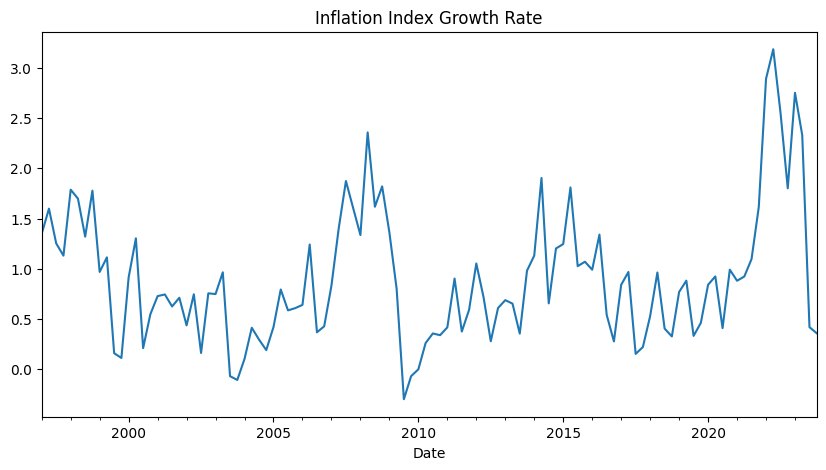

In [7]:
#plot inflation.index_growth
chl_data_qrt['inflation.index_growth'].plot(title='Inflation Index Growth Rate', figsize=(10, 5))

C:\Users\tfarotimi\AppData\Local\Temp\ipykernel_28308\2507905811.py:4: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  chl_data['inflation.index_yoy'] = chl_data['inflation.index'].pct_change(12)* 100


<Axes: title={'center': 'Inflation Index'}, xlabel='Date'>

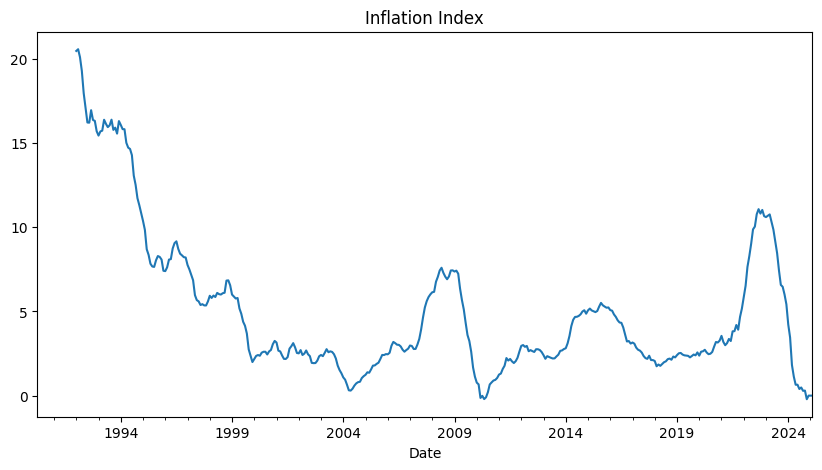

In [8]:
#plot chl_data['inflation']

#get yoy change of chl_data['inflation.index']
chl_data['inflation.index_yoy'] = chl_data['inflation.index'].pct_change(12)* 100

chl_data['inflation.index_yoy'].plot(title='Inflation Index', figsize=(10, 5))


In [9]:
chl_data['inflation.index_yoy'].dropna()

Date
1992-01-01    20.476610
1992-02-01    20.579006
1992-03-01    20.105237
1992-04-01    19.286247
1992-05-01    17.968494
                ...    
2024-10-01     0.299424
2024-11-01    -0.213871
2024-12-01     0.000000
2025-01-01     0.000000
2025-02-01     0.000000
Name: inflation.index_yoy, Length: 398, dtype: float64

In [10]:
chl_data_qrt['inflation.index_growth_annualized'].corr(chl_data['inflation.index_yoy'].dropna())

0.7242609979235562

In [11]:
#drop inflation.index and inflation.index_growth columns
chl_data_qrt = chl_data_qrt.drop(columns=['inflation.index', 'inflation.index_growth'])
chl_data_qrt    

,inflation.index_growth_annualized,inflation.expectaions,interest
Date,,,
1997-01-01,5.505429,7.515160,7.250000
1997-04-01,6.547993,6.168581,6.966631
1997-07-01,5.104259,5.474030,6.675000
1997-10-01,4.600425,5.439527,6.500000
1998-01-01,7.341272,5.898488,7.918254
...,...,...,...
2022-10-01,7.399113,10.858440,11.188596
2023-01-01,11.464004,10.707162,11.250000
2023-04-01,9.648151,9.779584,11.250000


In [12]:
#read gdp data from excel 
gdp_data = pd.read_excel("inputData/Holston_Laubach_Williams_current_estimates.xlsx", sheet_name="Chile Raw Data_GDP")
gdp_data.set_index("Date", inplace=True)
gdp_data.resample('QS').mean()
gdp_data = gdp_data.dropna()

#gdp_data = gdp_data/10000

gdp_data = np.log(gdp_data) 

#change date index format to quarter and year 
gdp_data.index = gdp_data.index.to_period('Q')
gdp_data





,gdp.raw
Date,
1996Q1,9.907163
1996Q2,9.917064
1996Q3,9.926983
1996Q4,9.941214
1997Q1,9.963638
...,...
2023Q3,10.839696
2023Q4,10.841651
2024Q1,10.861861


In [13]:
#change date index format to quarter and year 
chl_data_qrt.index = chl_data_qrt.index.to_period("Q")
chl_data_qrt.index.name = 'Date'
chl_data_qrt

,inflation.index_growth_annualized,inflation.expectaions,interest
Date,,,
1997Q1,5.505429,7.515160,7.250000
1997Q2,6.547993,6.168581,6.966631
1997Q3,5.104259,5.474030,6.675000
1997Q4,4.600425,5.439527,6.500000
1998Q1,7.341272,5.898488,7.918254
...,...,...,...
2022Q4,7.399113,10.858440,11.188596
2023Q1,11.464004,10.707162,11.250000
2023Q2,9.648151,9.779584,11.250000


In [14]:
#merge gdp_data and chl_data_qrt
chl_data_qrt = chl_data_qrt.merge(gdp_data, left_index=True, right_on='Date')
chl_data_qrt

,inflation.index_growth_annualized,inflation.expectaions,interest,gdp.raw
Date,,,,
1997Q1,5.505429,7.515160,7.250000,9.963638
1997Q2,6.547993,6.168581,6.966631,9.984237
1997Q3,5.104259,5.474030,6.675000,10.006575
1997Q4,4.600425,5.439527,6.500000,10.027638
1998Q1,7.341272,5.898488,7.918254,10.035639
...,...,...,...,...
2022Q4,7.399113,10.858440,11.188596,10.833972
2023Q1,11.464004,10.707162,11.250000,10.840936
2023Q2,9.648151,9.779584,11.250000,10.834711


In [15]:
# #test chl_data_qrt for stationarity

# from statsmodels.tsa.stattools import adfuller

# def adf_test(series):
#     result = adfuller(series)
#     print(f'ADF Statistic: {result[0]}')
#     print(f'p-value: {result[1]}')
#     print(f'Critical Values:')
#     for key, value in result[4].items():
#         print(f'\t{key}: {value}')

# adf_test(chl_data_qrt['inflation.expectations'])
# adf_test(chl_data_qrt['interest'])
# adf_test(chl_data_qrt['gdp.raw'])
# adf_test(chl_data_qrt['interest'] - chl_data_qrt['inflation.expectations'])

# #interpret the results
# #p-value is less than 0.05, so we reject the null hypothesis that the data is non-stationary
# #p-value is less than 0.05, so we reject the null hypothesis that the data is non-stationary

In [ ]:
#rename columns
chl_data_qrt.columns = ['inflation', 'inflation.expectations', 'interest', 'gdp.log']

#add columns of 0 called covid.indicator



,inflation,inflation.expectations,interest,gdp.log
Date,,,,
1997Q1,5.505429,7.515160,7.250000,9.963638
1997Q2,6.547993,6.168581,6.966631,9.984237
1997Q3,5.104259,5.474030,6.675000,10.006575
1997Q4,4.600425,5.439527,6.500000,10.027638
1998Q1,7.341272,5.898488,7.918254,10.035639
...,...,...,...,...
2022Q4,7.399113,10.858440,11.188596,10.833972
2023Q1,11.464004,10.707162,11.250000,10.840936
2023Q2,9.648151,9.779584,11.250000,10.834711


In [17]:
stringency = pd.read_csv("inputData/stringency.csv")
stringency_data = stringency[['CountryCode', 'Date', 'StringencyIndex_Average']]
stringency_data = stringency_data[stringency_data['CountryCode'] == 'CHL']
stringency_data = stringency_data.drop(columns=['CountryCode'])
# stringency_data['Date'] = pd.to_datetime(stringency_data['Date'])
stringency_data = stringency_data.set_index('Date')
#process 20200101 to 2020-01-01
stringency_data.index = pd.to_datetime(stringency_data.index, format='%Y%m%d')
stringency_data = stringency_data.resample('QS').mean()
stringency_data = stringency_data.rename(columns={'StringencyIndex_Average': 'covid.indicator'})
stringency_data.index = stringency_data.index.to_period('Q')
#add rows up to 2024Q1 with stringency declining linearly to 0
stringency_data = stringency_data.reindex(pd.period_range(start='2020Q1', end='2024Q1', freq='Q', name='Date'))
stringency_data.loc['2024Q1'] = 0
stringency_data = stringency_data.interpolate(method='linear')
#add rows forom 1990Q1 to 2019Q4 with stringency = 0
stringency_data = stringency_data.reindex(pd.period_range(start='1990Q1', end='2024Q1', freq='Q', name='Date'))
stringency_data = stringency_data.fillna(0)
stringency_data = stringency_data.dropna()
stringency_data

,covid.indicator
Date,
1990Q1,0.000000
1990Q2,0.000000
1990Q3,0.000000
1990Q4,0.000000
1991Q1,0.000000
...,...
2023Q1,11.243913
2023Q2,8.432935
2023Q3,5.621957


In [18]:
#if running without covid 
#stringency_data['covid.indicator'] = 0.0

In [19]:
#merge covid.indicator into chl_data_qrt
chl_data_qrt = chl_data_qrt.merge(stringency_data, left_index=True, right_on='Date')
chl_data_qrt

,inflation,inflation.expectations,interest,gdp.log,covid.indicator
Date,,,,,
1997Q1,5.505429,7.515160,7.250000,9.963638,0.000000
1997Q2,6.547993,6.168581,6.966631,9.984237,0.000000
1997Q3,5.104259,5.474030,6.675000,10.006575,0.000000
1997Q4,4.600425,5.439527,6.500000,10.027638,0.000000
1998Q1,7.341272,5.898488,7.918254,10.035639,0.000000
...,...,...,...,...,...
2022Q4,7.399113,10.858440,11.188596,10.833972,14.054891
2023Q1,11.464004,10.707162,11.250000,10.840936,11.243913
2023Q2,9.648151,9.779584,11.250000,10.834711,8.432935


In [26]:
#save data to excel
# chl_data_qrt.to_excel("inputData/Holston_Laubach_Williams_CHL.xlsx", sheet_name="CHL Input Data" )
chl_data_qrt.to_csv("inputData/Holston_Laubach_Williams_CHL.csv", index=True)

